# Analisis RFM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

retail_df = preprocessed_data

Luego de realizar la primera limpieza del dataset vamos a proceder a crear las variables para el RFM analysis y visualizar sus distribuciones.

El análisis RFM es una técnica de segmentación de clientes basada en su comportamiento de compra. Se utiliza para identificar grupos de clientes más valiosos y dirigir mejor las estrategias de marketing, fidelización y retención.

RFM es un acrónimo de:

- R de Recency: Cuánto tiempo ha pasado desde la última compra del cliente.
- F	de Frequency: Cuántas veces ha comprado el cliente en un período determinado.
- M de Monetary: Cuánto dinero ha gastado el cliente en total.

### Recency

Para el calculo del recency tomamos como fecha de referencia el ultimo dia del dataset mas uno.

In [ ]:
fecha_referencia = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)
fecha_referencia

Timestamp('2011-12-10 12:50:00')

Y usamos la fecha de invoice mas alta de cada cliente para restarle a esa fecha de referencia. Convertimos ese valor a dias.

In [ ]:
recency_df = retail_df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (fecha_referencia - recency_df['InvoiceDate']).dt.days
recency_df.head()

,CustomerID,InvoiceDate,Recency
0,12347.0,2011-12-07 15:52:00,2
1,12348.0,2011-09-25 13:13:00,75
2,12349.0,2011-11-21 09:51:00,19
3,12350.0,2011-02-02 16:01:00,310
4,12352.0,2011-11-03 14:37:00,36


### Frequency

Para el frequency lo unico que vamos a hacer es contar la cantidad de facturas unicas que hay para cada cliente.

In [ ]:
frequency_df = retail_df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)
frequency_df.head()

,CustomerID,Frequency
0,12347.0,7
1,12348.0,4
2,12349.0,1
3,12350.0,1
4,12352.0,7


### Monetary

Por ultimo, para monetary vamos a sumar crear una nueva columna en el dataframe original que contenga el valor de cada item. Luego vamos a realizar la suma de todos estos valores para cada cliente. Esto nos da el valor total de compra para cada cliente dentro del periodo del dataset.

In [ ]:
retail_df['TotalPrice'] = retail_df['Quantity'] * retail_df['UnitPrice']

monetary_df = retail_df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df.rename(columns={'TotalPrice': 'Monetary'}, inplace=True)
monetary_df.head()

,CustomerID,Monetary
0,12347.0,4310.00
1,12348.0,1437.24
2,12349.0,1457.55
3,12350.0,294.40
4,12352.0,1385.74


### Crear dataset final

Finalmente debemos unir todos los dataset creados segun el customerID.

In [ ]:
rfm_df = recency_df.merge(frequency_df, on='CustomerID')
rfm_df = rfm_df.merge(monetary_df, on='CustomerID')
rfm_df.drop(columns=['InvoiceDate'], inplace=True)
rfm_df.set_index('CustomerID', inplace=True)
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12347.0,2011-12-07 15:52:00,2,7,4310.00
1,12348.0,2011-09-25 13:13:00,75,4,1437.24
2,12349.0,2011-11-21 09:51:00,19,1,1457.55
3,12350.0,2011-02-02 16:01:00,310,1,294.40
4,12352.0,2011-11-03 14:37:00,36,7,1385.74


In [ ]:
print("Total de clientes: ", rfm_df.shape[0])

Total de clientes:  4333


### Analisis inicial

In [ ]:
rfm_df.describe()

In [ ]:
from sklearn.decomposition import PCA

def plot_rfm_distributions(df, title_suffix="", figsize=(18, 6)):
    plt.close()
    
    fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
    for idx,feature in enumerate(df.columns):
        sns.histplot(data=df,x=feature,ax=axes[idx],kde=True)
        axes[idx].set_xlabel(f'{feature}',fontsize = 10)
        axes[idx].set_title(f'Box Plot of {feature}')
    plt.tight_layout()
    plt.show()

    fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
    for idx,feature in enumerate(df.columns):
        sns.boxplot(data=df,x=feature, ax=axes[idx])
        axes[idx].set_xlabel(f'{feature}',fontsize = 10)
        axes[idx].set_title(f'Box Plot of {feature}')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    # Plot 1: Recency vs Monetary
    axes[0].scatter(df['Recency'], df['Monetary'], alpha=0.6)
    axes[0].set_xlabel('Recency (days)')
    axes[0].set_ylabel('Monetary ($)')
    axes[0].set_title('Recency vs Monetary')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Recency vs Frequency
    axes[1].scatter(df['Recency'], df['Frequency'], alpha=0.6)
    axes[1].set_xlabel('Recency (days)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Recency vs Frequency')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Frequency vs Monetary
    axes[2].scatter(df['Frequency'], df['Monetary'], alpha=0.6)
    axes[2].set_xlabel('Frequency')
    axes[2].set_ylabel('Monetary ($)')
    axes[2].set_title('Frequency vs Monetary')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(df)
    explained_variance = pca.explained_variance_ratio_
    plt.figure(figsize=(10, 8))
    plt.scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.6)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})')
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})')
    plt.title('PCA of RFM Data')
    plt.show()

In [ ]:
plot_rfm_distributions(rfm_df)

Observamos que en nuestra empresa la mayoria de los clientes tienen pocos pedidos y bajo gasto.

A simple vista observamos que las 3 variables tienen una distribución exponencial, siendo la de Recency la mas apreciable. Para el caso de Frequency y Monetary no resulta sencillo ver a simple vista la distribucion por completo debido a que existen pocas ocurrencias para los valores mayores. Por lo tanto, podríamos identificar aquellos registros que causan esto y analizarlos.

Analizamos registros con Frequency mayor a 40 y con Monetary mayor a 25000

In [ ]:
# Analizar registros con Frequency > 40
high_frequency = rfm_df[rfm_df['Frequency'] > 40]
print(f"Registros con Frequency > 40: {len(high_frequency)}")
if len(high_frequency) > 0:
    print("\nRegistros con Frequency > 40:")
    print(high_frequency.head())

# Analizar registros con Monetary > 25000
high_monetary = rfm_df[rfm_df['Monetary'] > 25000]
print(f"\nRegistros con Monetary > 25000: {len(high_monetary)}")
if len(high_monetary) > 0:
    print("\nRegistros con Monetary > 25000:")
    print(high_monetary.head())

# Verificar si hay registros que cumplan ambas condiciones
both_conditions = rfm_df[(rfm_df['Frequency'] > 40) & (rfm_df['Monetary'] > 25000)]
print(f"\nRegistros que cumplen ambas condiciones (Frequency > 40 Y Monetary > 25000): {len(both_conditions)}")
if len(both_conditions) > 0:
    print("\nRegistros que cumplen ambas condiciones:")
    print(both_conditions.head())


Registros con Frequency > 40: 23

Registros con Frequency > 40:
     CustomerID         InvoiceDate  Recency  Frequency  Monetary
325     12748.0 2011-12-09 12:20:00        1        205  31464.09
480     12971.0 2011-12-06 12:20:00        4         85  10969.76
561     13089.0 2011-12-07 09:02:00        3         97  58762.08
794     13408.0 2011-12-08 09:05:00        2         62  28102.04
995     13694.0 2011-12-06 09:32:00        4         50  65039.62

Registros con Monetary > 25000: 35

Registros con Monetary > 25000:
     CustomerID         InvoiceDate  Recency  Frequency   Monetary
54      12415.0 2011-11-15 14:22:00       24         20  124562.45
325     12748.0 2011-12-09 12:20:00        1        205   31464.09
452     12931.0 2011-11-18 12:39:00       22         15   42055.96
557     13081.0 2011-11-28 10:54:00       12         11   28337.38
561     13089.0 2011-12-07 09:02:00        3         97   58762.08

Registros que cumplen ambas condiciones (Frequency > 40 Y Monetary >

Como se aprecia, son pocos clientes para cada caso. Ademas se trata de clientes que muestran un comportamiento de compras altamente recurrente, con compras hechas recientemente y por consiguiente un buen flujo de dinero. Dicho esto, probablemente pertenezcan a un grupo selecto de clientes (Clientes VIP) que podrían ser analizados por aparte y dejar en manos de la clusterización al resto de clientes. Por lo tanto tenemos dos alternativas: 1) No considerar a los clientes VIP y que la clusterizacion sea para segmentar un "cliente promedio" en la empresa o 2) Trabajar con el total de los datos.

Consideramos que estos clientes, a pesar de ser pocos, son muy importantes. Representan clientes que tienen un alto valor de compra y que compran frecuentemente. Por lo tanto, decidimos trabajar con el total de los datos, por lo menos por el momento.

Eliminar estos "outliers" significaria perder informacion importante. Sin embargo, como bien sabemos, los outliers pueden generar problemas en clustering. Puede darse que estos grandes valores generen clusters de pocos clientes, cosa que no queremos.


### Transformaciones de los datos

A continuacion se muestran todas las transformaciones probadas para evaluar y ver cuales convienen para cada caso y en caso de cambiar de algoritmos volver a estas graficas para probar/escoger las mejores para cada algoritmo. Como primer abordaje intentaremos alcanzar la mejor combinacion de Transformador-Escalador para algoritmos de distancia euclideana como KMeans y Agglomerative probando distintas combinaciones.

In [ ]:
import numpy as np
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, StandardScaler, RobustScaler

def apply_transformations(df, only_scaled=False):
    std_scaler = StandardScaler()
    rob_scaled = RobustScaler()
    
    if only_scaled:
        return {
            'Standard': std_scaler.fit_transform(df),
            'Robust': rob_scaled.fit_transform(df),
        }
    # --------------- Log ---------------
    X_log = np.log1p(df)

    X_log_std_scaled = std_scaler.fit_transform(X_log)
    X_log_rob_scaled = rob_scaled.fit_transform(X_log)


    # --------- Yeo-Johnson transform ---------
    pt = PowerTransformer(method='yeo-johnson')
    X_pt = pt.fit_transform(df)

    X_pt_std_scaled = std_scaler.fit_transform(X_pt)
    X_pt_rob_scaled = rob_scaled.fit_transform(X_pt)


    # --------- Quantile transform ---------
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_qt = qt.fit_transform(df)

    X_qt_std_scaled = std_scaler.fit_transform(X_qt)
    X_qt_rob_scaled = rob_scaled.fit_transform(X_qt)

    return {
        'Log-Standard': X_log_std_scaled,
        'Log-Robust': X_log_rob_scaled,

        'Power-Standard': X_pt_std_scaled,
        'Power-Robust': X_pt_rob_scaled,

        'Quantile-Standard': X_qt_std_scaled,
        'Quantile-Robust': X_qt_rob_scaled,
    }


def plot_distributions(dataframes_dict, figsize=(15, 10)):
    """
    Plot distributions for multiple dataframes with different transformations.
    
    Parameters:
    -----------
    dataframes_dict : dict
        Dictionary with keys as transformation names and values as numpy arrays
    figsize : tuple
        Figure size (width, height)
    """
    n_transformations = len(dataframes_dict)
    n_features = dataframes_dict[list(dataframes_dict.keys())[0]].shape[1]
    
    fig, axes = plt.subplots(n_features, n_transformations, figsize=figsize)
    
    # If only one transformation, make axes 2D
    if n_transformations == 1:
        axes = axes.reshape(-1, 1)
    
    feature_names = ['Recency', 'Frequency', 'Monetary']
    
    for col_idx, (transformation_name, data) in enumerate(dataframes_dict.items()):
        for row_idx in range(n_features):
            ax = axes[row_idx, col_idx] if n_transformations > 1 else axes[row_idx]
            
            # Plot histogram
            ax.hist(data[:, row_idx], bins=30, alpha=0.7, edgecolor='black')
            ax.set_title(f'{transformation_name}\n{feature_names[row_idx]}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

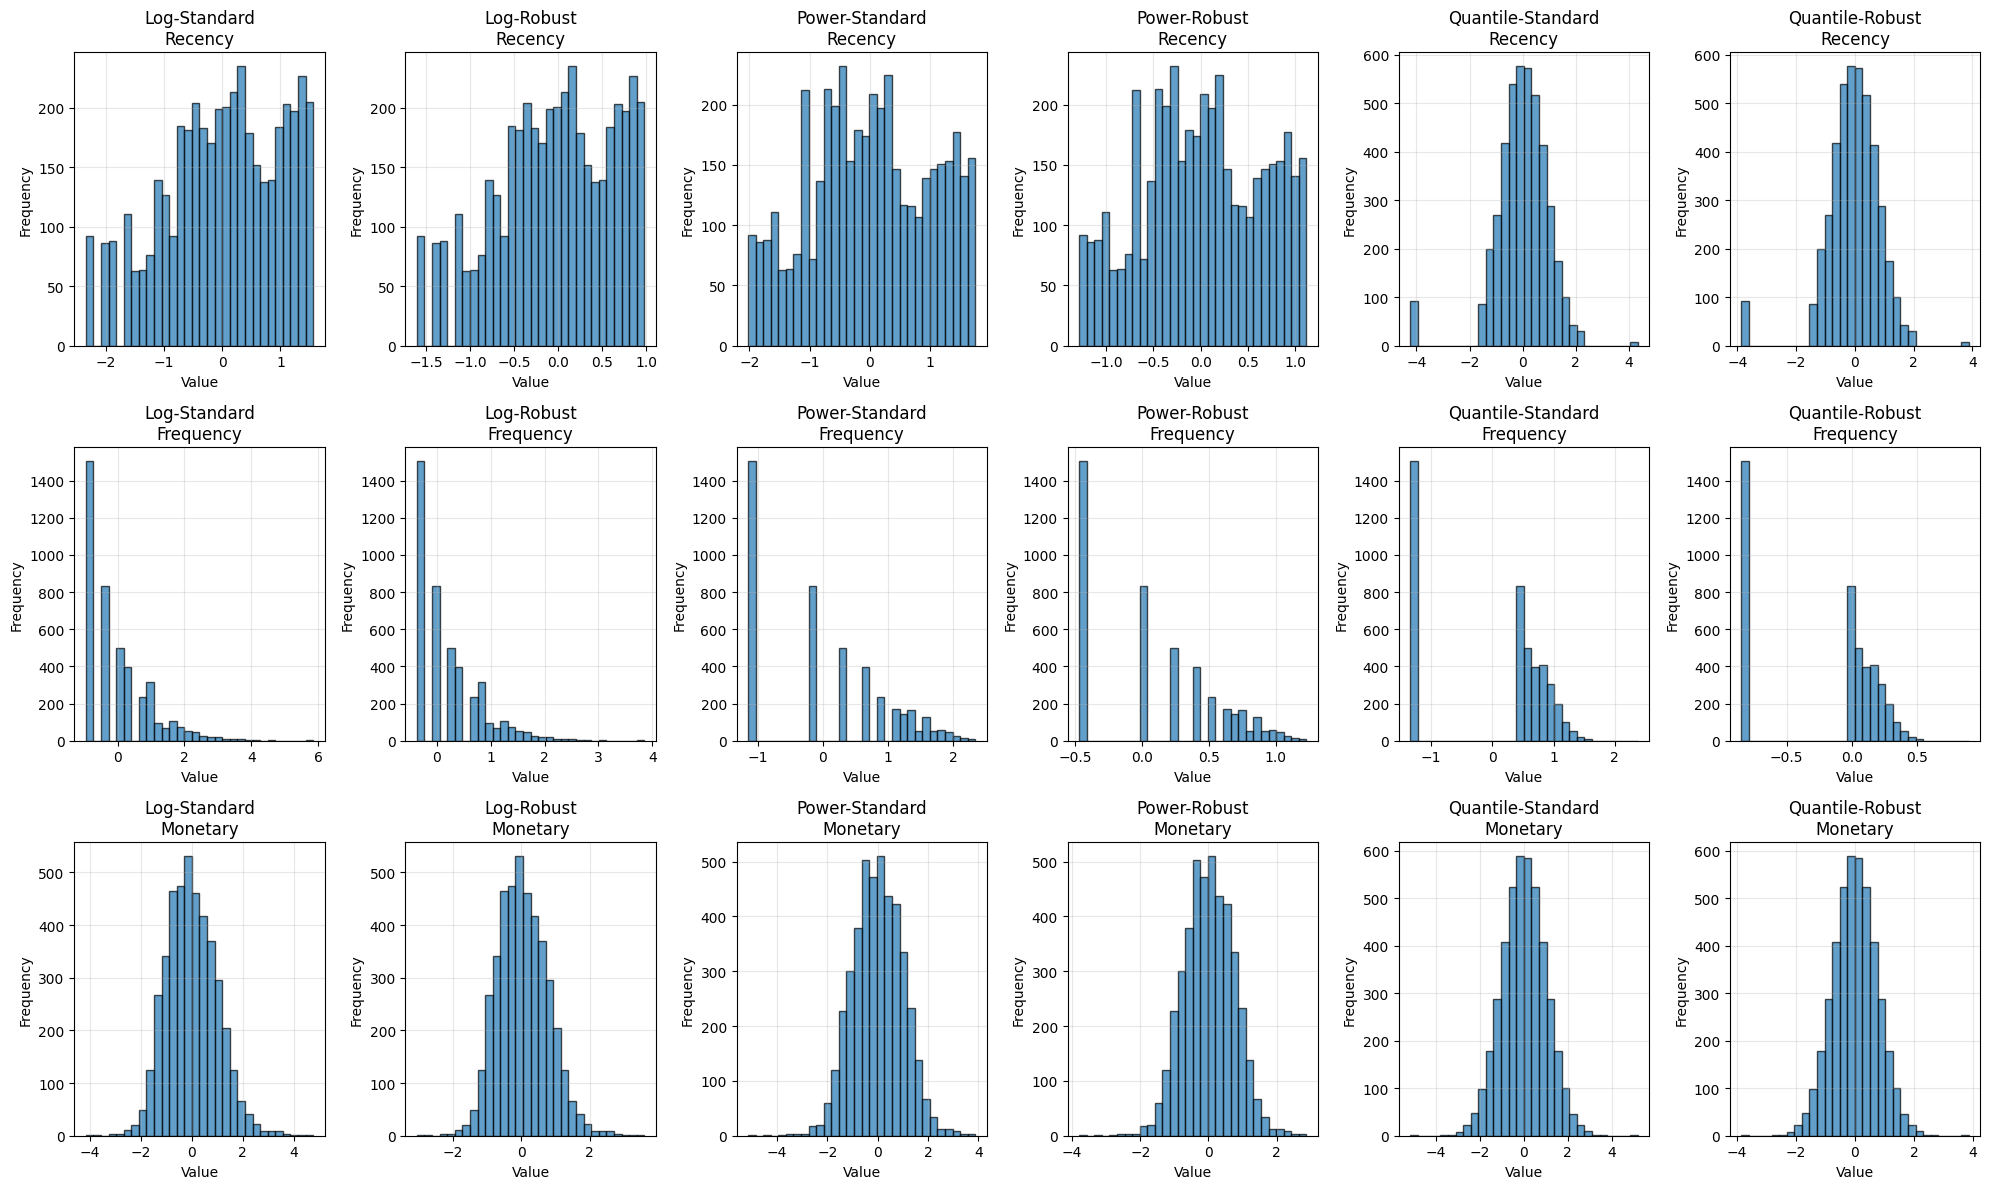

In [ ]:
transformations_dict = apply_transformations(rfm_df[['Recency', 'Frequency', 'Monetary']])

plot_distributions(transformations_dict, figsize=(20, 12))


Estos son algunos ejemplos de transformaciones que probamos.

Log y Power dieron resultados muy parecidos, con el mismo PCA salvo por algunas pequenias variaciones. Por lo que decidimos quedarnos con PowerStandard entre las dos. Despues tenemos el caso de QuantileTransformer, que logro resultados que tambien parecian prometedores.

Vamos a ver con algo mas de detalle como quedan los datos con RobustScaler, PowerStandard y QuantileTransformer.

#### PowerStandard



In [ ]:
from sklearn.preprocessing import PowerTransformer

power_df = rfm_df.copy()
pt = PowerTransformer(method='yeo-johnson')
power_df = pt.fit_transform(power_df)
power_df = pd.DataFrame(power_df, columns=rfm_df.columns)

plot_rfm_distributions(power_df)

Los resultados nos resultaron interesantes. En cuanto a las distribuciones se puede ver como mejoran mucho respecto a las originales. Los outliers se acercan al resto de datos y se realiza el escalado necesario para que las features no tengan escalas diferentes.

Sin embargo el PCA no nos termina de gustar. Se crea una nube de puntos en donde es dificil ver muy bien clusters definidos.

#### QuantileTransformer

In [ ]:
from sklearn.preprocessing import QuantileTransformer

quantile_df = rfm_df.copy()
qt = QuantileTransformer(output_distribution='normal', random_state=42)
quantile_df = qt.fit_transform(quantile_df)
quantile_df = pd.DataFrame(quantile_df, columns=rfm_df.columns)

plot_rfm_distributions(quantile_df)

Nuevamente las distribuciones quedan muy bien. Los datos quedan bastante normalizados y en PCA se logra ver clusters definidos. Sin embargo vemos algunas cuestiones un tanto extranias. 

Vemos como hay algunos valores que todavia estar separados del resto y nos llama la atencion la gran separacion que se produjo entre los datos (cosa que no habia pasado con ningun otro metodo).

Nos da un poco de miedo que esta haciendo exactamente QuantileTransformer sobre nuestros datos, no es facil saberlo y podria estar alterando demasiado algunos valores.

#### RobustScaler

Usamos Robust sobre Standard y MinMax porque tiene más resistencia a los outliers. Standard y MinMax son muy malos tratándolos. Robust, aunque no es el mejor, tiene mejores resultados.

In [ ]:
from sklearn.preprocessing import RobustScaler

robust_df = rfm_df.copy()
rs = RobustScaler()
robust_df = rs.fit_transform(robust_df)
robust_df = pd.DataFrame(robust_df, columns=rfm_df.columns)

plot_rfm_distributions(robust_df)

Robust no logra manejar los datos de la mejor manera. Claramente esto es un problema para el clustering, tenemos datos muy alejados del resto que crearan sus propios clusteres. No podemos permitir eso.

Sin embargo, podemos tomar algunas medidas con esos outliers. En este caso, para no eliminarlos, decidimos fijar un valor limite para las features. Este valor correspondera a los percentiles 10 y 90. Esto nos permite que aquellos valores que estan por encima del 90% de los datos no se alejen demasiado del resto como para crear sus propios clusteres. Sin embargo, al fijar el valor al percentil 95, seguiran teniendo valores lo suficientemente altos para diferenciarse del resto.

Es decir, sabemos que esos valores estan por encima del 90% de clientes y consideramos que saber eso es suficiente. No nos importa si el valor es extremadamente alto porque no queremos crear un cluster exclusivo para ese cliente. Nos alcanza saber que gasta mas que el resto.

Fijar los limites con percentiles se conoce como Winsorization.

In [ ]:
def winsorize_by_percentile(data, lower_percentile=5, upper_percentile=95):
    """
    Aplica winsorización a un DataFrame o a una Serie de Pandas.

    Los valores por debajo del percentil inferior se reemplazarán por el valor
    del percentil inferior. Los valores por encima del percentil superior se
    reemplazarán por el valor del percentil superior.

    Parámetros:
    -----------
    data : pd.DataFrame o pd.Series
        El conjunto de datos al que se aplicará la winsorización.
        Si es un DataFrame, la winsorización se aplica columna por columna.
        Si es una Serie, se aplica a la Serie.
    lower_percentile : int o float, opcional (default=5)
        El percentil inferior (e.g., 5 para el 5to percentil).
        Debe estar entre 0 y 100.
    upper_percentile : int o float, opcional (default=95)
        El percentil superior (e.g., 95 para el 95to percentil).
        Debe estar entre 0 y 100.

    Retorna:
    --------
    pd.DataFrame o pd.Series
        Los datos con la winsorización aplicada.
    """

    if not (0 <= lower_percentile < upper_percentile <= 100):
        raise ValueError("Los percentiles deben estar entre 0 y 100, "
                         "y lower_percentile debe ser menor que upper_percentile.")

    # Convertir a DataFrame si la entrada es una Serie para manejar ambos casos uniformemente
    if isinstance(data, pd.Series):
        is_series = True
        df = data.to_frame()
    elif isinstance(data, pd.DataFrame):
        is_series = False
        df = data.copy() # Trabajar con una copia para no modificar el DataFrame original
    else:
        raise TypeError("La entrada debe ser un pd.DataFrame o pd.Series.")

    winsorized_df = pd.DataFrame(index=df.index, columns=df.columns)

    for column in df.columns:
        # Asegurarse de que la columna sea numérica
        if pd.api.types.is_numeric_dtype(df[column]):
            lower_bound = np.percentile(df[column].dropna(), lower_percentile)
            upper_bound = np.percentile(df[column].dropna(), upper_percentile)

            winsorized_col = df[column].clip(lower=lower_bound, upper=upper_bound)
            winsorized_df[column] = winsorized_col
        else:
            # Si no es numérica, simplemente copiar la columna
            winsorized_df[column] = df[column]

    return winsorized_df.iloc[:, 0] if is_series else winsorized_df

In [ ]:
winsorized_df = winsorize_by_percentile(rfm_df, lower_percentile=10, upper_percentile=90)
winsorized_df = rs.fit_transform(winsorized_df)
winsorized_df = pd.DataFrame(winsorized_df, columns=rfm_df.columns)

plot_rfm_distributions(winsorized_df)

Como vemos ahora los datos estan mas cerca, no hay grandes outliers que nos roben clusters y gracias a robust se logra hacer el escalado.

Quizas no es el metodo que mejor deja las distribuciones, pero nos asegura que los datos no han sido modificados incorrectamente. Sentimos mas control a pesar de que no esten del todo normalizados.

### ¿Con qué transformación nos quedamos?

No estamos seguros del todo cuál es la mejor. Quizás depende del algoritmo. Sin embargo creemos que la mejor es con RobustScaler. Esto debido a que, tras hacer algunas pruebas, nos dimos cuenta de dos cuestiones.

PowerStandard transforma demasiado los datos, ya habíamos mencionado que se generaba esa nube de puntos donde no parecía haber diferencias. Además, cuando quisimos agregar nuevas variables vimos que no se podían percibir los cambios en esa nube. Estabamos cambiando los datos, agregando variables, quitando variables, y el plot de PCA parecia siempre el mismo aunque los resultados del clustering si cambiaban. Esto hizo que PowerStandard no sea considerada buena opción.

Por otro lado, Quantile, como lo habíamos notado, tenia algo extraño. Básicamente los cluster separados que se formaban eran los datos de frecuencia uno o recencia uno. Esto generaba que los modelos generen clusters de esos dos grupos sin importarle demasiado el monetary, por ejemplo. Esto obviamente afectaba el análisis. No sabemos porque exactamente Quantile sobre-exageraba estos valores y los separaba tanto del resto, pero hacia que no nos sirva.

Robust con winsorization al final demostró que los resultados con RFM eran similares a los de PowerStandard, y aquí si podíamos ver los cambios en el plot de PCA cuando queríamos probar algo. Por esa razón terminamos eligiendo esta transformación en primera instancia.